In [ ]:
+from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
pip install sklearn-genetic sklearn-genetic-opt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 11.0 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import os
import random
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

from sklearn_genetic import GAFeatureSelectionCV

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
data_dir = "/content/drive/MyDrive/Brain_Stroke/Updated_Dataset"

filepaths = []
labels = []

for label in os.listdir(data_dir):
    class_path = os.path.join(data_dir, label)
    for file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, file))
        labels.append(label)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

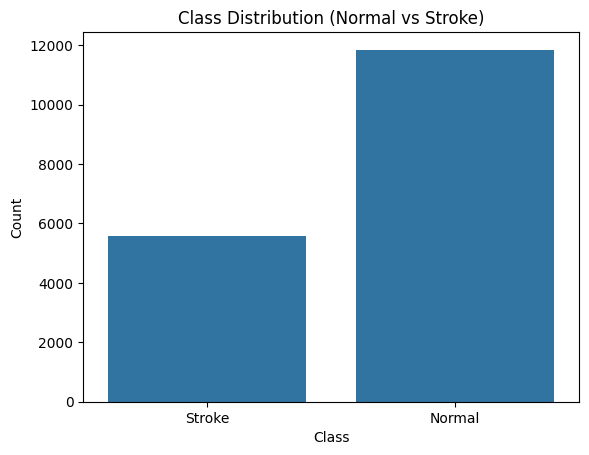

In [ ]:
sns.countplot(x=df['class'])
plt.title('Class Distribution (Normal vs Stroke)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

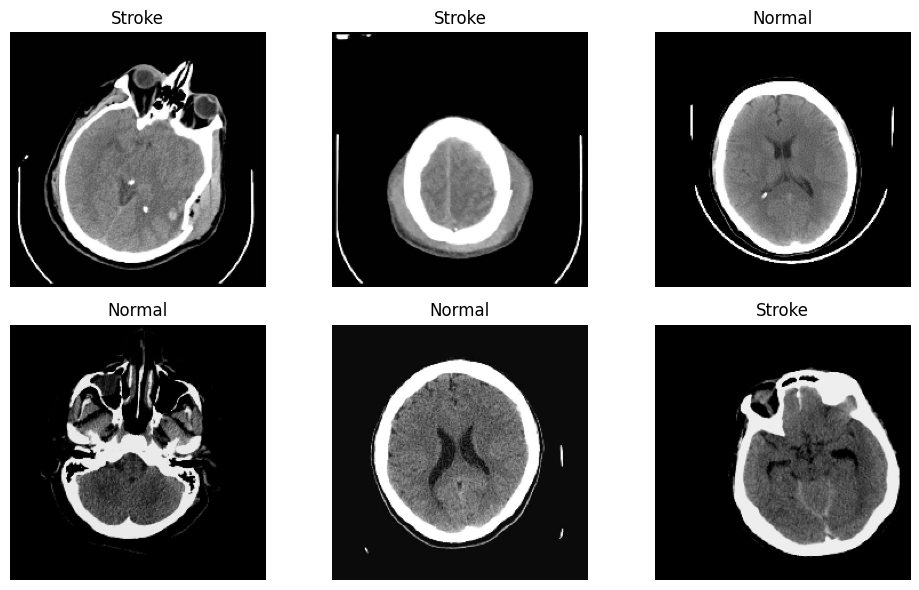

In [ ]:
sample_paths = df.sample(6, random_state=42)

plt.figure(figsize=(10,6))
for i, row in enumerate(sample_paths.itertuples()):
    plt.subplot(2,3,i+1)
    img = load_img(row.filename, target_size=(224,224))
    plt.imshow(img)
    plt.title(row._2)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.3,
    stratify=df["class"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["class"],
    random_state=42
)

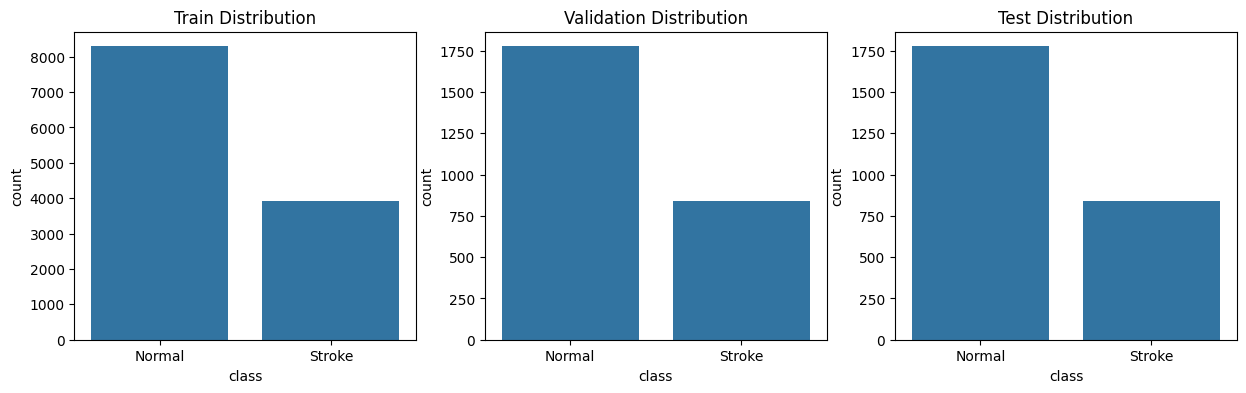

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(15,4))

sns.countplot(x=train_df['class'], ax=axes[0])
axes[0].set_title('Train Distribution')

sns.countplot(x=val_df['class'], ax=axes[1])
axes[1].set_title('Validation Distribution')

sns.countplot(x=test_df['class'], ax=axes[2])
axes[2].set_title('Test Distribution')

plt.show()

In [ ]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=True
)

val_gen = test_datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    shuffle=False
)

Found 12201 validated image filenames belonging to 2 classes.
Found 2614 validated image filenames belonging to 2 classes.
Found 2615 validated image filenames belonging to 2 classes.


In [ ]:
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(224,224,3))

x = base_model.output
x = GlobalAveragePooling2D()(x)

model = Model(inputs=base_model.input, outputs=x)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def extract_features(generator, model):
    generator.reset()
    features = []
    labels = []

    steps = int(np.ceil(generator.samples / generator.batch_size))

    for _ in range(steps):
        x, y = next(generator)
        feat = model.predict(x, verbose=0)
        features.append(feat)
        labels.append(y)

    return np.vstack(features), np.hstack(labels)

In [ ]:
X_train, y_train = extract_features(train_gen, model)
X_val, y_val = extract_features(val_gen, model)
X_test, y_test = extract_features(test_gen, model)

In [ ]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

In [ ]:
ga = GAFeatureSelectionCV(
    estimator=LogisticRegression(max_iter=1000, class_weight= class_weights),
    cv=3,
    scoring="recall",
    population_size=15,
    generations=15,
    n_jobs=-1,
    verbose=True
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('ga', ga),
    ('clf', LogisticRegression(max_iter=1000, class_weight= class_weights))
])

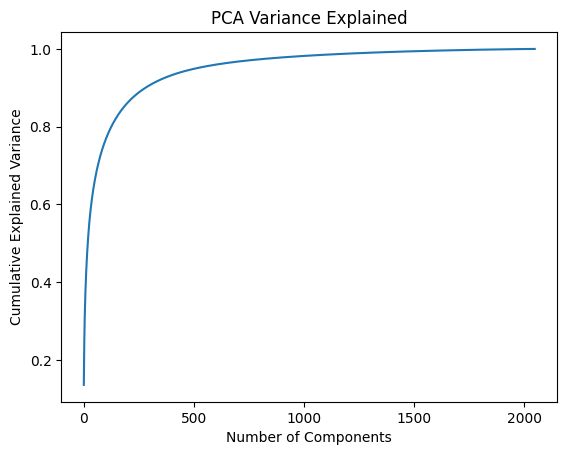

In [ ]:
pca_temp = PCA().fit(X_train)

plt.plot(np.cumsum(pca_temp.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA Variance Explained')
plt.show()

In [ ]:
print(X_train.shape, y_train.shape)

(12201, 2048) (12201,)


In [ ]:
pipeline.fit(X_train, y_train)

gen	nevals	fitness 	fitness_std	fitness_max	fitness_min
0  	15    	0.672991	0.0290316  	0.7156     	0.62327    
1  	30    	0.706681	0.00583282 	0.7156     	0.696928   
2  	30    	0.709512	0.00547226 	0.7156     	0.69923    
3  	30    	0.705522	0.0126366  	0.7156     	0.677487   
4  	30    	0.702145	0.0146611  	0.7156     	0.677487   
5  	30    	0.693143	0.0241611  	0.7156     	0.638872   
6  	30    	0.692018	0.0154598  	0.7156     	0.649358   
7  	30    	0.698684	0.0149866  	0.7156     	0.658823   
8  	30    	0.697081	0.016747   	0.7156     	0.658823   
9  	30    	0.704191	0.0116354  	0.7156     	0.675446   
10 	30    	0.693535	0.0277378  	0.714318   	0.631454   
11 	30    	0.703935	0.0137455  	0.714318   	0.661893   
12 	30    	0.708573	0.00868772 	0.7202     	0.681073   
13 	30    	0.703713	0.0184741  	0.7202     	0.657031   
14 	30    	0.698786	0.0195481  	0.7202     	0.655755   
15 	30    	0.695308	0.0237429  	0.7202     	0.643988   


Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.9)),
                ('ga',
                 GAFeatureSelectionCV(estimator=LogisticRegression(class_weight={np.float32(0.0): np.float64(0.735797853093716),
                                                                                 np.float32(1.0): np.float64(1.560230179028133)},
                                                                   max_iter=1000),
                                      generations=15, n_jobs=-1,
                                      population_size=15, scoring='recall')),
                ('clf',
                 LogisticRegression(class_weight={np.float32(0.0): np.float64(0.735797853093716),
                                                  np.float32(1.0): np.float64(1.560230179028133)},
                                    max_iter=1000))])

In [ ]:
y_val_pred = pipeline.predict(X_val)
y_val_prob = pipeline.predict_proba(X_val)[:,1]

print(f"The accuracy on test data : {accuracy_score(y_val,y_val_pred)}\n")
print(classification_report(y_val, y_val_pred))

The accuracy on test data : 0.7681713848508034

              precision    recall  f1-score   support

         0.0       0.86      0.79      0.82      1776
         1.0       0.62      0.73      0.67       838

    accuracy                           0.77      2614
   macro avg       0.74      0.76      0.75      2614
weighted avg       0.78      0.77      0.77      2614



In [ ]:
y_test_pred = pipeline.predict(X_test)
y_test_prob = pipeline.predict_proba(X_test)[:,1]

print(f"The accuracy on test data : {accuracy_score(y_test,y_test_pred)}\n")
print(classification_report(y_test, y_test_pred))

The accuracy on test data : 0.7521988527724666

              precision    recall  f1-score   support

         0.0       0.85      0.78      0.81      1777
         1.0       0.60      0.70      0.64       838

    accuracy                           0.75      2615
   macro avg       0.72      0.74      0.73      2615
weighted avg       0.77      0.75      0.76      2615



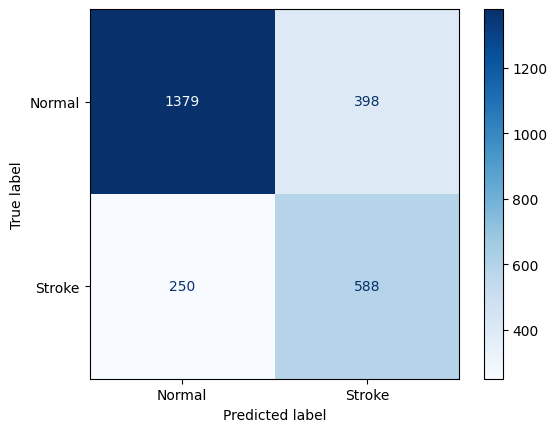

In [ ]:
cm = confusion_matrix(y_test, y_test_pred)
labels = ["Normal", "Stroke"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues")

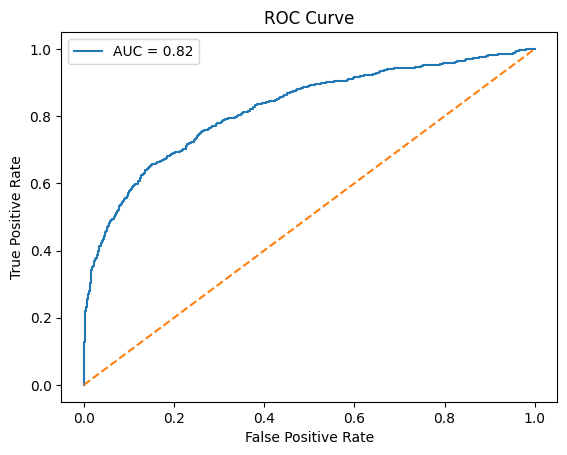

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_test_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [ ]:
model.save('/content/drive/MyDrive/Brain_Stroke/InceptionV3/LogisticRegression/inceptionv3(logreg).keras')
joblib.dump(pipeline, '/content/drive/MyDrive/Brain_Stroke/InceptionV3/LogisticRegression/pipeline(logreg).pkl')

['/content/drive/MyDrive/Brain_Stroke/InceptionV3/LogisticRegression/pipeline(logreg).pkl']

In [ ]:
model = keras.models.load_model('/content/drive/MyDrive/Brain_Stroke/InceptionV3/LogisticRegression/inceptionv3(logreg).keras')
pipeline = joblib.load('/content/drive/MyDrive/Brain_Stroke/InceptionV3/LogisticRegression/pipeline(logreg).pkl')